In [64]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# True probability of success
p = 0.7

# Generate 100 Bernoulli samples
samples = rng.binomial(n=1, p=p, size=100)

print(samples[:20])


[0 1 0 1 1 0 0 0 1 1 1 0 1 0 1 1 1 1 0 1]


In [65]:
# Calculate the theoretical mean and variance using the Bernoulli formulas.
mean = p
variance = p * (1 - p)

print("Theoretical Mean: ", mean)
print("Theoretical Variance: ", variance)

# Calculate the empirical mean and variance using NumPy
empirical_mean = np.mean(samples)
empirical_variance = np.var(samples)

print("Empirical Mean: ", empirical_mean)
print("Empirical Variance: ", empirical_variance)

Theoretical Mean:  0.7
Theoretical Variance:  0.21000000000000002
Empirical Mean:  0.73
Empirical Variance:  0.19710000000000005


In [66]:
# Repeat the experiment with 10, 100, 1,000 and 10,000 samples.
sample_sizes = [10, 100, 1000, 10000]

empirical_means = []

for n in sample_sizes:
    samples = rng.binomial(n=1, p=p, size=n)
    empirical_means.append(np.mean(samples))

print(empirical_means)

[np.float64(0.5), np.float64(0.72), np.float64(0.69), np.float64(0.7046)]


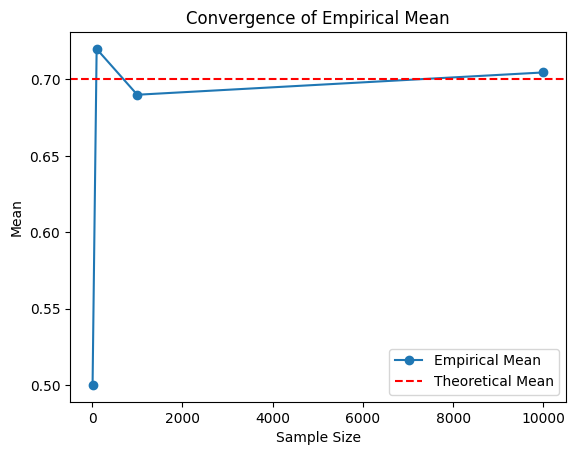

In [67]:
plt.plot(sample_sizes, empirical_means, 'o-', label='Empirical Mean')
plt.axhline(y=mean, linestyle='--', label='Theoretical Mean', color='r')

plt.xlabel('Sample Size')
plt.ylabel('Mean')
plt.title('Convergence of Empirical Mean')
plt.legend()
plt.show()

In [69]:
# Explain why your empirical results change when you increase the sample size
# As the sample size increases, the empirical results (mean and variance) tend to converge towards the 
# theoretical values. This is due to the Law of Large Numbers, which states that as the number of trials or 
# samples increases, the sample mean will get closer to the expected value (theoretical mean).

Empirical mean: 6.9994
Empirical variance: 2.09279964


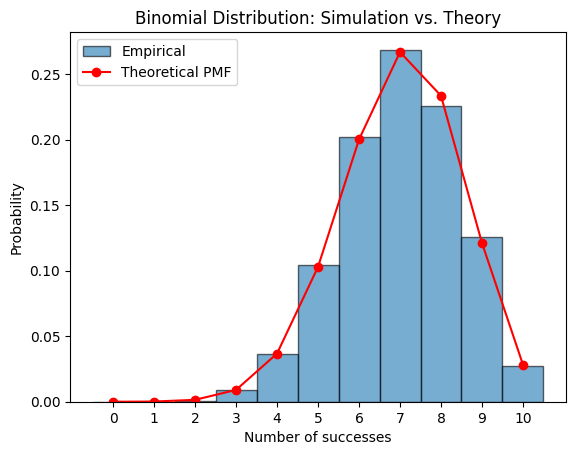

In [71]:
from math import comb

samples = rng.binomial(n=10, p=p, size=10000)  # 10000 samples of 10 trials each
n = 10
# empirical mean and variance 
empirical_mean = np.mean(samples)
empirical_variance = np.var(samples)

print("Empirical mean:", empirical_mean)
print("Empirical variance:", empirical_variance)

# Theoretical probability for each possible count of successes
k = np.arange(n + 1)
pmf = np.array([
    comb(n, int(value)) * p**value * (1 - p)**(n - value)
    for value in k
])

# Integer-centered bins and weights make the histogram show probabilities
bins = np.arange(-0.5, n + 1.5, 1)
plt.hist(
    samples,
    bins=bins,
    weights=np.ones(samples.size) / samples.size,
    alpha=0.6,
    edgecolor="black",
    label="Empirical",
)
plt.plot(k, pmf, "o-", color="red", label="Theoretical PMF")

plt.xlabel("Number of successes")
plt.ylabel("Probability")
plt.title("Binomial Distribution: Simulation vs. Theory")
plt.xticks(k)
plt.legend()
plt.show()
